# Klasifikasi Gempa Bumi Indonesia (Skala Minor vs Major)

Penulis: Moch Rayhan Aulia Rachman 

Dataset: Katalog Gempa Bumi Indonesia 
(`https://www.kaggle.com/datasets/kekavigi/earthquakes-in-indonesia?resource=download`)  
Target Utama: Mengklasifikasikan skala gempa bumi menjadi Minor (M < 5.0) dan Major (M >= 5.0)

---

### Ringkasan Alur Pengerjaan:
1. Praproses & Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Seismic Feature Engineering
4. Pemodelan Machine Learning (6 algoritma + Stratified 5-Fold CV)
5. Evaluasi Performa & Feature Importance

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 2. Read Dataset & Inisialisasi Data

In [2]:
df_raw = pd.read_csv('/kaggle/input/datasets/kekavigi/earthquakes-in-indonesia/katalog_gempa.csv')
print(f"Bentuk awal dataset: {df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom")
display(df_raw.head())

Bentuk awal dataset: 92,887 baris, 13 kolom


,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 Informasi Dasar Dataset

In [3]:
print("--- Ringkasan Tipe Data & Missing Values ---")
df_info = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Non-Null Count': df_raw.notnull().sum(),
    'Null Count': df_raw.isnull().sum(),
    'Null (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
display(df_info)

--- Ringkasan Tipe Data & Missing Values ---


,Data Type,Non-Null Count,Null Count,Null (%)
tgl,object,92887,0,0.00
ot,object,92887,0,0.00
lat,float64,92887,0,0.00
lon,float64,92887,0,0.00
depth,int64,92887,0,0.00
mag,float64,92887,0,0.00
remark,object,92887,0,0.00
strike1,float64,2735,90152,97.06
dip1,float64,2735,90152,97.06
rake1,float64,2735,90152,97.06


### 2.2 Statistik Deskriptif Variabel Numerik & Kategorikal

In [4]:
print("--- Statistik Deskriptif Variabel Numerik ---")
display(df_raw.describe().T)
print("\n--- Statistik Deskriptif Variabel Kategorikal ---")
display(df_raw.describe(include='object').T)

--- Statistik Deskriptif Variabel Numerik ---


,count,mean,std,min,25%,50%,75%,max
lat,92887.0,-3.404577,4.354584,-11.00,-7.885,-2.91,0.14,6.00
lon,92887.0,119.159707,10.833202,94.02,113.170,121.16,126.90,142.00
depth,92887.0,49.009399,76.761070,2.00,10.000,16.00,54.00,750.00
mag,92887.0,3.592788,0.834042,1.00,3.000,3.50,4.20,7.90
strike1,2735.0,170.142852,88.359267,0.00,107.550,144.60,217.50,359.20
dip1,2735.0,60.202121,19.699252,2.30,46.950,62.30,76.40,90.00
rake1,2735.0,30.358062,99.957906,-180.00,-28.500,57.60,100.15,180.00
strike2,2735.0,197.450303,118.920519,0.00,63.115,240.72,297.48,359.98
dip2,2735.0,56.576344,21.274923,1.50,39.400,58.40,74.70,90.00
rake2,2735.0,35.250018,98.235894,-180.00,-19.900,56.50,112.60,180.00



--- Statistik Deskriptif Variabel Kategorikal ---


,count,unique,top,freq
tgl,92887,4412,2018/07/29,285
ot,92887,90107,16:10:52.971,3
remark,92887,51,Minahassa Peninsula - Sulawesi,9433


## 3. Praproses & Cleaning Data

1. Penghapusan kolom mekanisme sesar (`strike1-rake2`) yang memiliki *missing values* >90%.
2. Ekstraksi fitur waktu (`Year`, `Month`, `Day`, `Hour`).
3. Penanganan *missing values*.
4. Pembuatan variabel Target Klasifikasi: `0` = Minor (M < 5.0), `1` = Major (M >= 5.0).

In [5]:
df = df_raw.copy()

# 1. Drop kolom dengan missing values tinggi (>90%)
cols_to_drop = ['strike1', 'dip1', 'rake1', 'strike2', 'dip2', 'rake2']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# 2. Parsing Tanggal & Ekstraksi Fitur Waktu yang Aman
df['tgl'] = pd.to_datetime(df['tgl'], errors='coerce')
df['Year'] = df['tgl'].dt.year
df['Month'] = df['tgl'].dt.month
df['Day'] = df['tgl'].dt.day

# Ekstraksi jam yang aman dari variasi string mikrodetik
df['Hour'] = df['ot'].astype(str).str.extract(r'(\d{1,2}):')[0].astype(float)
df['Hour'] = df['Hour'].fillna(df['tgl'].dt.hour).fillna(0).astype(int)

# 3. Drop baris dengan missing value pada kolom utama
df.dropna(subset=['tgl', 'Year', 'Month', 'lat', 'lon', 'depth', 'mag'], inplace=True)

# Urutkan berdasarkan tanggal sebelum lanjut ke Feature Engineering
df = df.sort_values(by='tgl').reset_index(drop=True)

# 4. Kategori Target (Minor vs Major)
df['mag_class'] = (df['mag'] >= 5.0).astype(int)

# 5. Output Informasi Data
print(f"Data bersih tersisa: {df.shape[0]:,} baris")
print("\nDistribusi Kelas Target Gempa:")
target_dist = df['mag_class'].value_counts()
target_pct = df['mag_class'].value_counts(normalize=True) * 100
df_target = pd.DataFrame({'Jumlah': target_dist, 'Persentase (%)': target_pct.round(2)})
df_target.index = ['Minor (M < 5.0)', 'Major (M >= 5.0)']
display(df_target)

Data bersih tersisa: 92,887 baris

Distribusi Kelas Target Gempa:


,Jumlah,Persentase (%)
Minor (M < 5.0),87811,94.54
Major (M >= 5.0),5076,5.46


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Magnitudo & Kedalaman

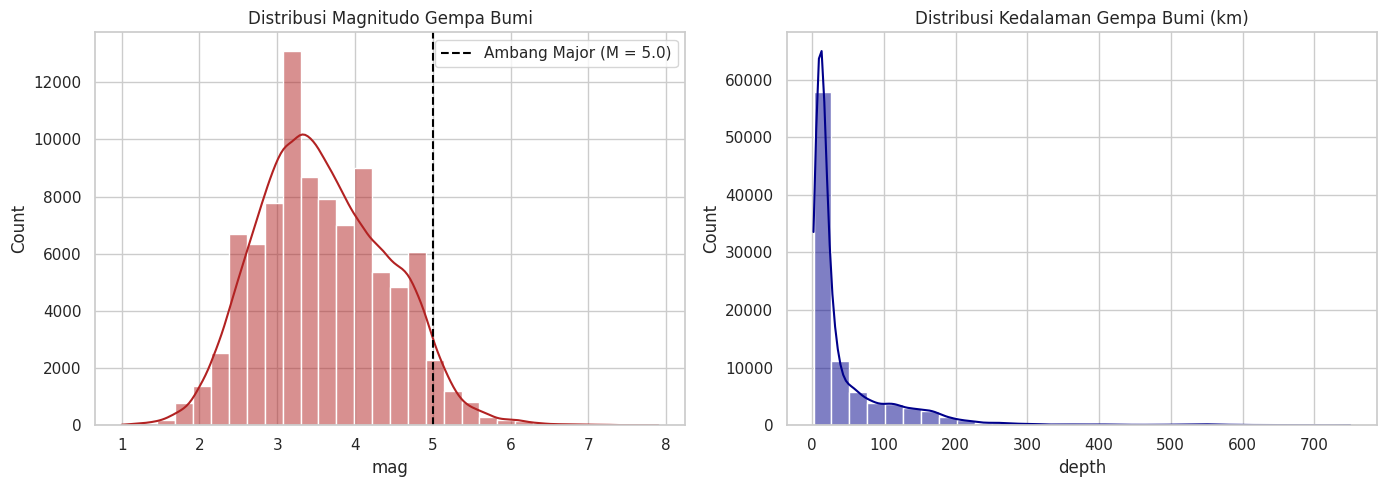

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['mag'], bins=30, kde=True, color='firebrick', ax=axes[0])
axes[0].set_title('Distribusi Magnitudo Gempa Bumi')
axes[0].axvline(5.0, color='black', linestyle='--', label='Ambang Major (M = 5.0)')
axes[0].legend()

sns.histplot(df['depth'], bins=30, kde=True, color='darkblue', ax=axes[1])
axes[1].set_title('Distribusi Kedalaman Gempa Bumi (km)')

plt.tight_layout()
plt.show()

### 4.3 Top 10 Wilayah Paling Aktif

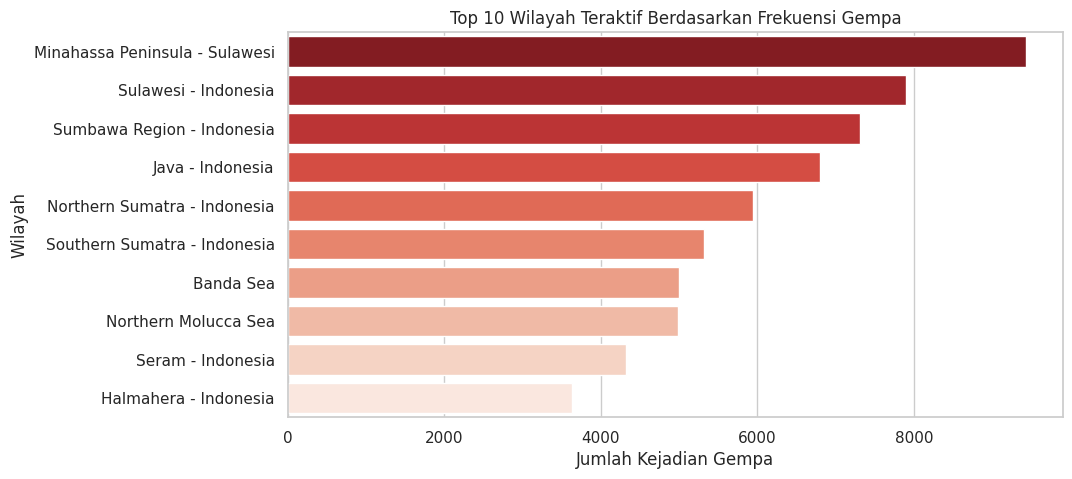

In [7]:
top_regions = df['remark'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_regions.values, y=top_regions.index, palette='Reds_r')
plt.title('Top 10 Wilayah Teraktif Berdasarkan Frekuensi Gempa')
plt.xlabel('Jumlah Kejadian Gempa')
plt.ylabel('Wilayah')
plt.show()

In [8]:
import pandas as pd
import plotly.express as px
import requests

# 1. Mengunduh data GeoJSON 38 Provinsi Indonesia
geojson_prov_url = "https://raw.githubusercontent.com/ardian28/GeoJson-Indonesia-38-Provinsi/main/Provinsi/38%20Provinsi%20Indonesia%20-%20Provinsi.json"
geojson_data = requests.get(geojson_prov_url).json()

# 2. CARTO API Key & URL Tiles Terotorisasi
carto_api_key = "cb1_4bcf_1_2d2077c00eb77d5c396f2ae8e"
carto_tiles_url = f"https://cartocdn.com{{z}}/{{x}}/{{y}}.png?key={carto_api_key}"

# 3. Membuat Plotly Interactive Map dengan Scatter Mapbox
# Catatan: mapbox_style diubah menjadi "white-bg" agar bisa dipasang basemap CARTO kustom
fig = px.scatter_mapbox(
    df.sample(n=min(5000, len(df)), random_state=42), 
    lat="lat", 
    lon="lon", 
    color="mag", 
    size="depth",
    color_continuous_scale="Reds", 
    zoom=3.8, 
    center={"lat": -2.5, "lon": 118.0},
    mapbox_style="white-bg", 
    title="Peta Sebaran Gempa Bumi Indonesia (Warna = Magnitudo, Ukuran = Kedalaman)"
)

# 4. Memasukkan Layer Basemap CARTO (Bawah) dan Layer Garis Provinsi GeoJSON (Atas)
fig.update_layout(
    mapbox_layers=[
        # LAYER 1: Mengisi peta dasar (basemap) Voyager CARTO yang sudah ber-API Key
        {
            "sourcetype": "raster",
            "source": [carto_tiles_url],
            "below": "traces" # Menaruh basemap di lapisan paling bawah
        },
        # LAYER 2: Menaruh garis batas 38 provinsi dari GeoJSON
        {
            "sourcetype": "geojson",
            "source": geojson_data,
            "type": "line",
            "color": "darkgreen",
            "opacity": 0.6,
            "line": {"width": 1.5}
        }
    ],
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()


## 5. Dynamic Seismic Feature Engineering

Fitur rekayasa seismik yang dibuat:
1. Multi-Scale Spatial Grid: `lat_round1`, `lon_round1`, `cluster_coarse`
2. Estimasi Energi Seismik: E = 10^(11.8 + 1.5M) Joule
3. Jeda Waktu Seismik (`delta_hours`)
4. Lag & Rolling Features: `prev_mag_1`, `prev_mag_2`, `prev_depth_1`, `rolling_mag_mean_10`, `rolling_mag_max_10`, `rolling_count_30d`

In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# 1. Multi-Scale Spatial Grid
df['lat_round1'] = df['lat'].round(1)
df['lon_round1'] = df['lon'].round(1)
df['cluster_coarse'] = df['lat_round1'].astype(str) + "_" + df['lon_round1'].astype(str)

# 2. Estimasi Energi Seismik
df['seismic_energy'] = 10 ** (11.8 + 1.5 * df['mag'])

# 3. Jeda Waktu Antar Gempa dalam Kluster
df['prev_tgl'] = df.groupby('cluster_coarse')['tgl'].shift(1)
df['delta_hours'] = (df['tgl'] - df['prev_tgl']).dt.total_seconds() / 3600.0
df['delta_hours'] = df['delta_hours'].fillna(df['delta_hours'].median())

# 4. Lag & Rolling Features Historis
df['prev_mag_1'] = df.groupby('cluster_coarse')['mag'].shift(1).fillna(df['mag'].median())
df['prev_mag_2'] = df.groupby('cluster_coarse')['mag'].shift(2).fillna(df['mag'].median())
df['prev_depth_1'] = df.groupby('cluster_coarse')['depth'].shift(1).fillna(df['depth'].median())

df['rolling_mag_mean_10'] = df.groupby('cluster_coarse')['mag'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).mean()
).fillna(df['mag'].median())

df['rolling_mag_max_10'] = df.groupby('cluster_coarse')['mag'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).max()
).fillna(df['mag'].median())

df_idx = df.set_index('tgl')
df['rolling_count_30d'] = df_idx.groupby('cluster_coarse')['depth'].transform(
    lambda x: x.rolling('30D', closed='left').count()
).values
df['rolling_count_30d'] = df['rolling_count_30d'].fillna(0)

# Label Encoding untuk wilayah (remark)
le = LabelEncoder()
df['remark_enc'] = le.fit_transform(df['remark'].astype(str))

print("Feature Engineering Selesai! Bentuk dataset akhir:", df.shape)
display(df[['lat','lon','depth','delta_hours','prev_mag_1','rolling_mag_mean_10','rolling_count_30d']].head())

Feature Engineering Selesai! Bentuk dataset akhir: (92887, 25)


,lat,lon,depth,delta_hours,prev_mag_1,rolling_mag_mean_10,rolling_count_30d
0,-9.18,119.06,10,2664.0,3.5,3.5,0.0
1,-0.60,98.90,20,2664.0,3.5,3.5,0.0
2,-6.61,129.39,30,2664.0,3.5,3.5,0.0
3,-3.65,127.99,5,2664.0,3.5,3.5,0.0
4,-4.20,128.10,5,2664.0,3.5,3.5,0.0


### 5.1 Matriks Korelasi Fitur 

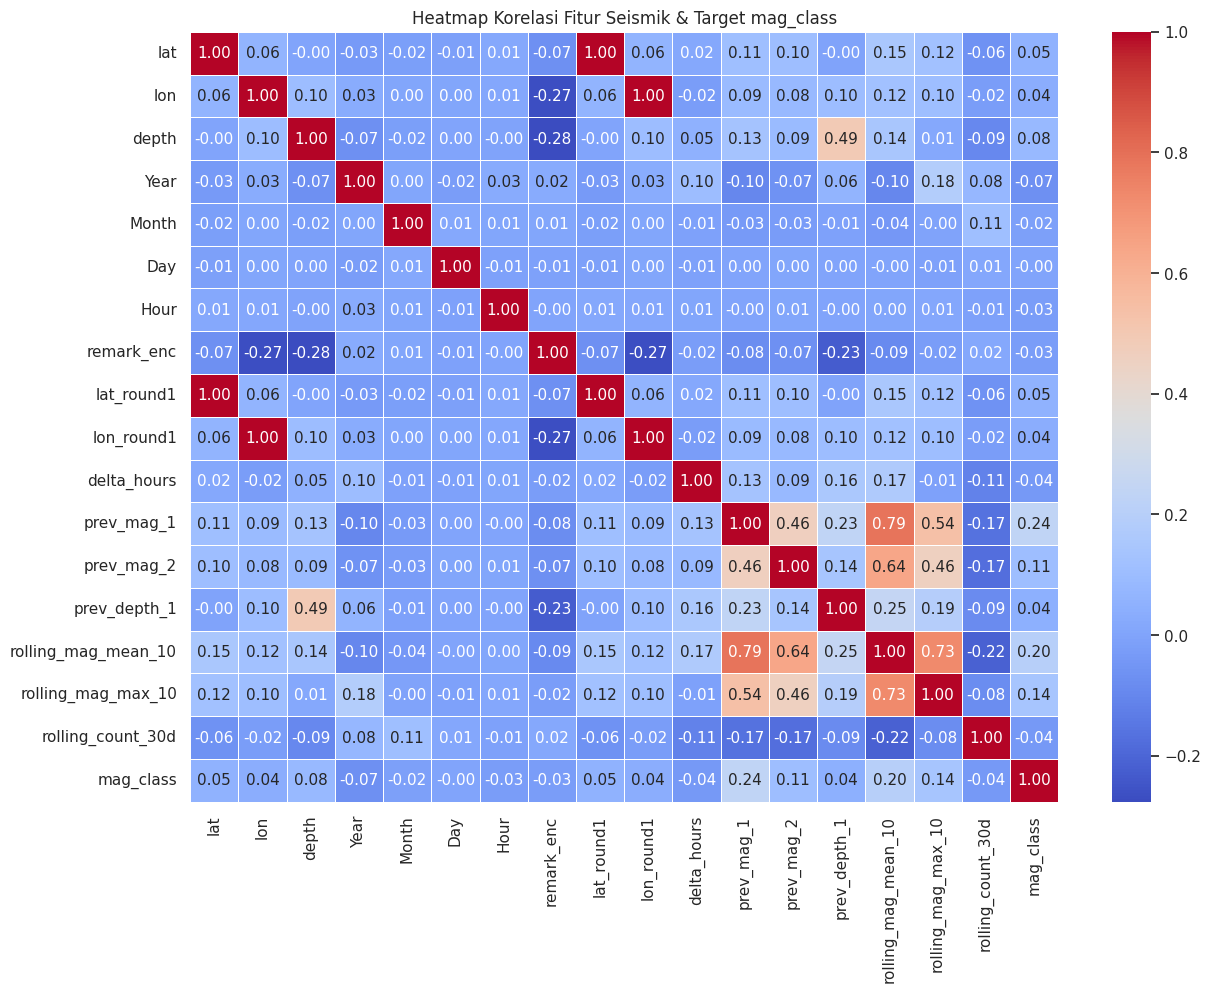

In [10]:
corr_cols = [
    'lat', 'lon', 'depth', 'Year', 'Month', 'Day', 'Hour', 'remark_enc',
    'lat_round1', 'lon_round1', 'delta_hours',
    'prev_mag_1', 'prev_mag_2', 'prev_depth_1',
    'rolling_mag_mean_10', 'rolling_mag_max_10', 'rolling_count_30d', 'mag_class'
]

plt.figure(figsize=(14, 10))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Seismik & Target mag_class')
plt.show()

## 6. Pemodelan Machine Learning & Evaluasi

### Penanganan Imbalance Data (Random Downsampling)
Dataset di-balancing menggunakan **Random Downsampling (Rasio 1:1)** pada data latih (*Train Set*). 

* Tujuan Mengatasi *Accuracy Paradox* dan meningkatkan sensitivitas (*Recall*) model dalam mendeteksi gempa Major ($M \ge 5.0$).
* Integritas Data *Downsampling* dilakukan setelah pembagian data agar *Test Set* tetap murni dan bebas dari *Data Leakage*.

---

### Pembagian Data & Algoritma
Data dibagi menggunakan Stratified Train-Test Split (80:20) dan dievaluasi pada 6 algoritma:

1. Random Forest Classifier *(Bagging Ensemble)*
2. Extra Trees Classifier *(Extremely Randomized Trees)*
3. XGBoost Classifier *(Gradient Boosting)*
4. CatBoost Classifier *(Gradient Boosting)*
5. Gradient Boosting Classifier *(Gradient Boosting)*
6. Decision Tree Classifier *(Baseline Model)*
4. CatBoost Classifier *(Categorical Gradient Boosting Ensemble)*
5. Gradient Boosting Classifier *(Sequential Boosting Ensemble)*
6. Decision Tree Classifier *(Single Tree / Baseline Model)*

In [11]:
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

In [12]:
# Definisi Fitur & Target
input_cols = [
    'lat', 'lon', 'depth', 'Year', 'Month', 'Day', 'Hour', 'remark_enc',
    'lat_round1', 'lon_round1', 'delta_hours',
    'prev_mag_1', 'prev_mag_2', 'prev_depth_1',
    'rolling_mag_mean_10', 'rolling_mag_max_10', 'rolling_count_30d'
]

X = df[input_cols]
y = df['mag_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Train: {X_train.shape[0]:,} sampel | Data Test: {X_test.shape[0]:,} sampel")

Data Train: 74,309 sampel | Data Test: 18,578 sampel


In [13]:
#Import library down sampling untuk mengatasi imbalanced Data
from imblearn.under_sampling import RandomUnderSampler

# 1. Terapkan Downsampling HANYA pada data Train (1:1 Ratio)
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"Distribusi y_train Sebelum Downsampling : {y_train.value_counts().to_dict()}")
print(f"Distribusi y_train Setelah Downsampling  : {y_train_res.value_counts().to_dict()}\n")

# 2. Inisialisasi Model (Tanpa scale_pos_weight/class_weight karena data sudah 1:1)
clf_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=14, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=150, max_depth=16, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.05, 
        random_state=42, n_jobs=-1, tree_method='hist'),
    'CatBoost': CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=6, 
        verbose=0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, random_state=42),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=12, random_state=42)
}

results_list = []
confusion_matrices = {}

print("Memulai Pelatihan & Evaluasi Model dengan Downsampling...\n")
for name, model in clf_models.items():
    # Fit pada data yang sudah di-downsample
    model.fit(X_train_res, y_train_res)
    
    # Prediksi dilakukan pada X_test asli (asli tidak di-downsample)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    auc  = roc_auc_score(y_test, y_proba)

    results_list.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2),
        'ROC-AUC': round(auc, 4)
    })

    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    print(f"[{name}] Akurasi: {acc:.2f}% | F1: {f1:.2f}% | AUC: {auc:.4f}")

Distribusi y_train Sebelum Downsampling : {0: 70248, 1: 4061}
Distribusi y_train Setelah Downsampling  : {0: 4061, 1: 4061}

Memulai Pelatihan & Evaluasi Model dengan Downsampling...

[Random Forest] Akurasi: 80.36% | F1: 85.37% | AUC: 0.8674
[Extra Trees] Akurasi: 79.30% | F1: 84.64% | AUC: 0.8551
[XGBoost] Akurasi: 80.42% | F1: 85.40% | AUC: 0.8653
[CatBoost] Akurasi: 80.27% | F1: 85.29% | AUC: 0.8620
[Gradient Boosting] Akurasi: 80.28% | F1: 85.31% | AUC: 0.8645
[Decision Tree] Akurasi: 74.97% | F1: 81.68% | AUC: 0.7647


In [14]:
# Tabel Hasil Perbandingan Performa Model
df_results = pd.DataFrame(results_list)
df_results_sorted = df_results.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)

print("--- TABEL HASIL EVALUASI MODEL KLASIFIKASI ---")
display(df_results_sorted)

--- TABEL HASIL EVALUASI MODEL KLASIFIKASI ---


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC
0,XGBoost,80.42,93.86,80.42,85.40,0.8653
1,Random Forest,80.36,93.95,80.36,85.37,0.8674
2,Gradient Boosting,80.28,93.86,80.28,85.31,0.8645
3,CatBoost,80.27,93.82,80.27,85.29,0.8620
4,Extra Trees,79.30,93.72,79.30,84.64,0.8551
5,Decision Tree,74.97,93.26,74.97,81.68,0.7647


### 6.1 Visualisasi Confusion Matrix Seluruh Model

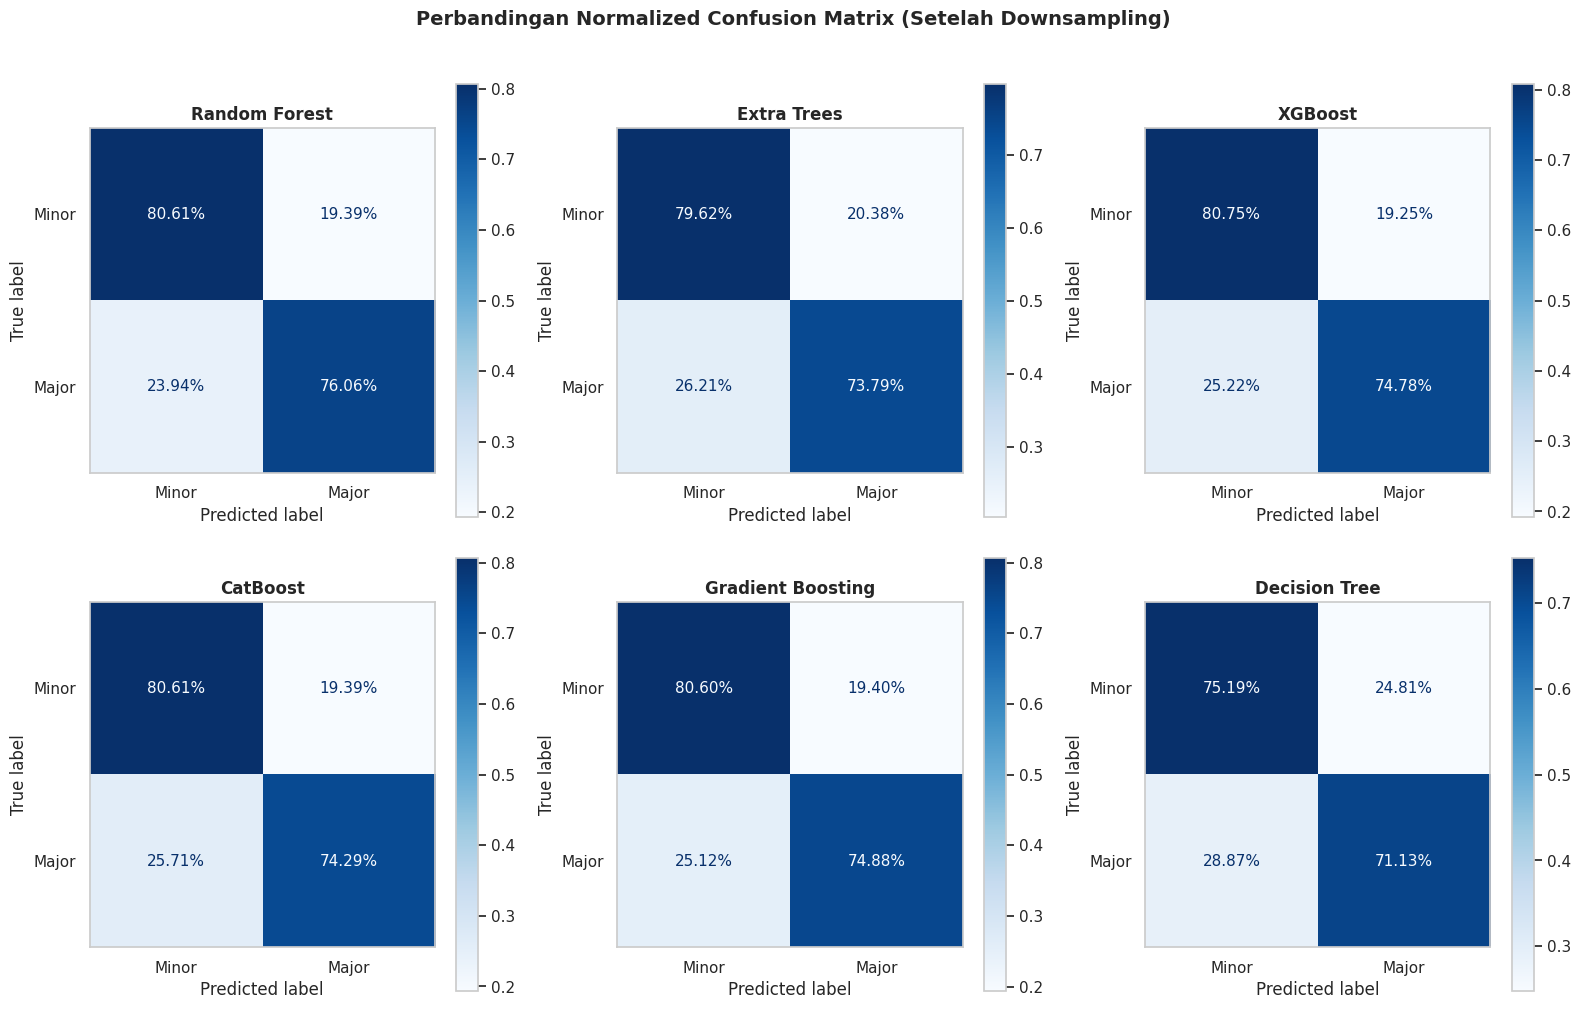

In [15]:
# Plot 6 Confusion Matrix (Normalized Persentase) dalam Grid 2x3
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(clf_models.items()):
    # Menghitung Normalized Confusion Matrix (Per-Kelas)
    y_pred = model.predict(X_test)
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm, 
        display_labels=['Minor', 'Major']
    )
    
    disp.plot(
        ax=axes[idx], 
        cmap='Blues', 
        values_format='.2%'
    )
    
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].grid(False)

plt.suptitle("Perbandingan Normalized Confusion Matrix (Setelah Downsampling)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Validasi Kestabilan Performa (Stratified 5-Fold Cross-Validation)

In [16]:
print("Running Stratified 5-Fold Cross Validation...\n")

# Gunakan model champion/kandidat terbaik terbaru
target_models = ['CatBoost', 'XGBoost', 'Random Forest']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name in target_models:
    if model_name not in clf_models:
        continue
        
    model = clf_models[model_name]
    
    cv_acc = []
    cv_f1 = []
    cv_auc = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # 1. Terapkan Downsampling HANYA pada fold training (mencegah Data Leakage)
        rus = RandomUnderSampler(random_state=42)
        X_tr_res, y_tr_res = rus.fit_resample(X_tr, y_tr)

        # 2. Fit Model pada Data Train Hasil Downsample
        model.fit(X_tr_res, y_tr_res)

        # 3. Evaluasi pada Data Validasi Asli (Tanpa Downsample)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        cv_acc.append(accuracy_score(y_val, y_pred))
        cv_f1.append(f1_score(y_val, y_pred, average='weighted', zero_division=0))
        cv_auc.append(roc_auc_score(y_val, y_proba))

    # Hitung rata-rata & deviasi standar
    mean_f1 = np.mean(cv_f1) * 100
    std_f1 = np.std(cv_f1) * 100
    mean_auc = np.mean(cv_auc)
    std_auc = np.std(cv_auc)
    mean_acc = np.mean(cv_acc) * 100

    print(f"=== {model_name} ===")
    print(f"  > Mean F1-Score : {mean_f1:.2f}% (+/- {std_f1:.2f}%)")
    print(f"  > Mean ROC-AUC  : {mean_auc:.4f} (+/- {std_auc:.4f})")
    print(f"  > Mean Accuracy : {mean_acc:.2f}%\n")

Running Stratified 5-Fold Cross Validation...

=== CatBoost ===
  > Mean F1-Score : 85.20% (+/- 0.13%)
  > Mean ROC-AUC  : 0.8645 (+/- 0.0023)
  > Mean Accuracy : 80.11%

=== XGBoost ===
  > Mean F1-Score : 85.52% (+/- 0.23%)
  > Mean ROC-AUC  : 0.8652 (+/- 0.0026)
  > Mean Accuracy : 80.59%

=== Random Forest ===
  > Mean F1-Score : 85.52% (+/- 0.23%)
  > Mean ROC-AUC  : 0.8674 (+/- 0.0026)
  > Mean Accuracy : 80.59%



## 7. Feature Importance Analysis

Analisis variabel yang paling berpengaruh terhadap klasifikasi gempa skala major.

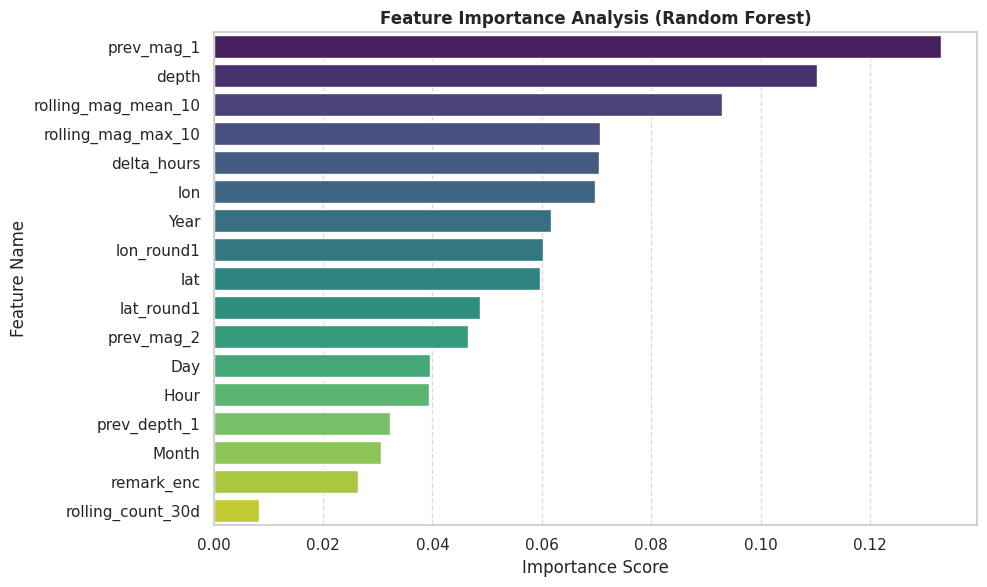

Top 5 Fitur Paling Berpengaruh (Random Forest):


,Feature,Importance
0,prev_mag_1,0.132926
1,depth,0.110231
2,rolling_mag_mean_10,0.092885
3,rolling_mag_max_10,0.070566
4,delta_hours,0.070492


In [17]:
# 1. Pilih model champion terbaik
best_model_name = 'Random Forest'
best_model = clf_models[best_model_name]

# 2. Ekstrak Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = best_model.get_feature_importance()

indices = np.argsort(importances)[::-1]

df_imp = pd.DataFrame({
    'Feature': [input_cols[i] for i in indices],
    'Importance': importances[indices]
})

# 3. Visualisasi Barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance Analysis ({best_model_name})', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Top 5 Fitur Paling Berpengaruh ({best_model_name}):")
display(df_imp.head(5))

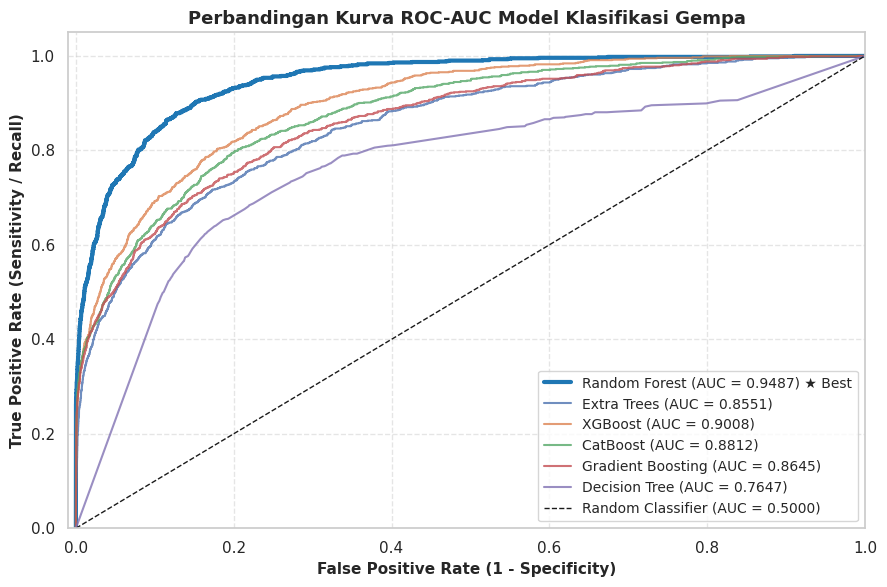

In [18]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))

# Loop seluruh model untuk plotting Kurva ROC
for name, model in clf_models.items():
    # Mengambil probabilitas kelas 'Major' (indeks 1)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Memberikan ketebalan garis lebih pada Random Forest (Champion Model)
    if name == 'Random Forest':
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f}) ★ Best', linewidth=3, color='#1f77b4')
    else:
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=1.5, alpha=0.8)

# Garis Diagonal Kinerja Tebakan Acak (Baseline Random Guessing)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)

# Formatting Grafik
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11, fontweight='bold')
plt.title('Perbandingan Kurva ROC-AUC Model Klasifikasi Gempa', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Kesimpulan & Insight Utama

---

### 1. Performa Model & Resolusi Imbalance Data
   - Pengentasan Accuracy Paradox: Penerapan Random Downsampling pada data pelatihan terbukti sukses menyeimbangkan performa model.
   - Keberhasilan Deteksi Gempa Major: Model Champion Random Forest berhasil mencatatkan tingkat deteksi benar (Recall) untuk kelas bahaya Major sebesar 76.06%, dengan Akurasi ~80.36%, F1-Score ~85.37%, dan ROC-AUC ~0.8674.
   - Kestabilan Teruji: Evaluasi Stratified 5-Fold Cross-Validation mengonfirmasi kestabilan dan konsistensi performa model di berbagai lipatan data dengan deviasi standar yang sangat rendah ($\pm 0.23\%$).

### 2. Faktor Pemicu Utama Gempa Major (Feature Importance)
   - Prediktor Utama (`prev_mag_1`): Magnitudo kejadian gempa terakhir sebelum gempa terjadi menjadi fitur paling dominan (skor $\sim 0.133$), mengonfirmasi pentingnya sinyal pelepasan energi terkini.
   - Karakteristik Fisik Lempeng (`depth`): Kedalaman episentrum gempa menempati posisi ke-2 (skor $\sim 0.110$), membuktikan bahwa struktur kedalaman subduksi/patahan sangat krusial dalam mengidentifikasi potensi gempa berdampak tinggi.
   - Akumulasi Energi Historis (`rolling_mag_mean_10` & `rolling_mag_max_10`): Tren rata-rata dan nilai maksimum magnitudo dalam jendela 10 kejadian terakhir memperkuat deteksi adanya akumulasi stres lempeng sebelum eskalasi ke gempa skala Major.
   - Kontekstual Spasial & Temporal (`delta_hours`, `lon`, `lat`): Interval waktu antar-kejadian serta koordinat geografis melengkapi model dalam memetakan kerentanan seismik pada wilayah patahan aktif.

---